# Análise Exploratória de Dados (EDA)
Montagem inicial da análise exploratória de dados.

In [30]:
import pandas as pd

file_path = 'data/teste_indicium_precificacao.csv'
df = pd.read_csv(file_path)
df = df[df['price'] > 0]
df = df[df['disponibilidade_365'] > 0]
df = df.drop(['host_id', 'host_name', 'ultima_review', 'calculado_host_listings_count'], axis=1)
df.describe()

,id,latitude,longitude,price,minimo_noites,numero_de_reviews,reviews_por_mes,disponibilidade_365
count,3.135300e+04,31353.000000,31353.000000,31353.000000,31353.000000,31353.000000,26146.000000,31353.000000
mean,2.100560e+07,40.728409,-73.948752,162.092240,8.338660,31.850094,1.810124,175.828406
std,1.148734e+07,0.056561,0.051400,254.448797,23.839305,51.639221,1.805664,126.192864
min,2.595000e+03,40.499790,-74.244420,10.000000,1.000000,0.000000,0.010000,1.000000
25%,1.167431e+07,40.688400,-73.983280,70.000000,2.000000,2.000000,0.450000,55.000000
50%,2.256150e+07,40.723730,-73.954110,112.000000,3.000000,10.000000,1.230000,168.000000
75%,3.119458e+07,40.763040,-73.930150,189.000000,5.000000,39.000000,2.680000,305.000000
max,3.648724e+07,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,365.000000


A primeira análise feita foi de distribuição de preços para verificar se existe grande variação de valores no dataset.

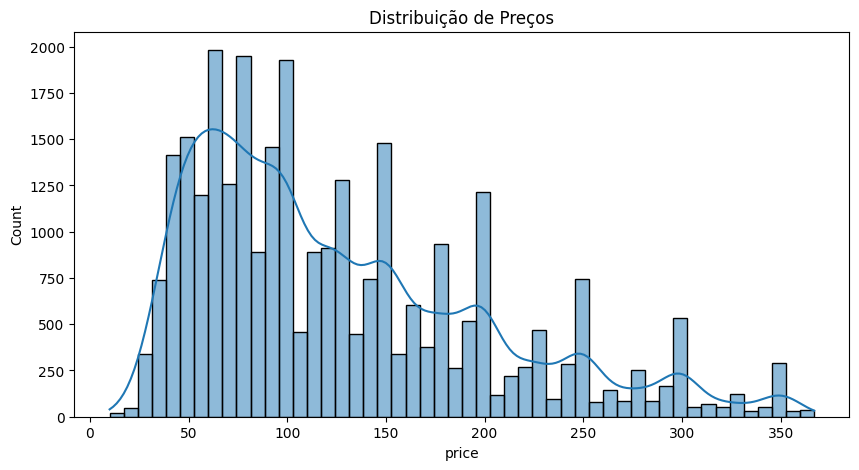

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribuição de Preços')
plt.show()

Análise dos valores e identificação de outliers. Foi feita a remoção dos itens com esses valores para não criar ruídos na análise final.

In [33]:
import numpy as np

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1R:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite Inferior:", limite_inferior)
print("Limite Superior:", limite_superior)

df = df[(df['price'] >= limite_inferior) & (df['price'] <= limite_superior)]

Q1R: 69.0
Q3: 170.0
IQR: 101.0
Limite Inferior: -82.5
Limite Superior: 321.5


In [34]:
df.describe()

,id,latitude,longitude,price,minimo_noites,numero_de_reviews,reviews_por_mes,disponibilidade_365
count,2.892400e+04,28924.000000,28924.000000,28924.000000,28924.000000,28924.000000,24431.000000,28924.000000
mean,2.084152e+07,40.727776,-73.946721,122.185521,8.271366,33.124222,1.831689,172.665952
std,1.147866e+07,0.057671,0.051994,68.889385,23.314043,52.680362,1.822314,125.986496
min,2.595000e+03,40.499790,-74.244420,10.000000,1.000000,0.000000,0.010000,1.000000
25%,1.145359e+07,40.687390,-73.981630,67.000000,1.000000,2.000000,0.460000,53.000000
50%,2.234246e+07,40.721760,-73.952250,100.000000,3.000000,11.000000,1.260000,161.000000
75%,3.105258e+07,40.763430,-73.927877,165.000000,5.000000,42.000000,2.710000,301.000000
max,3.648724e+07,40.913060,-73.712990,321.000000,1250.000000,629.000000,58.500000,365.000000


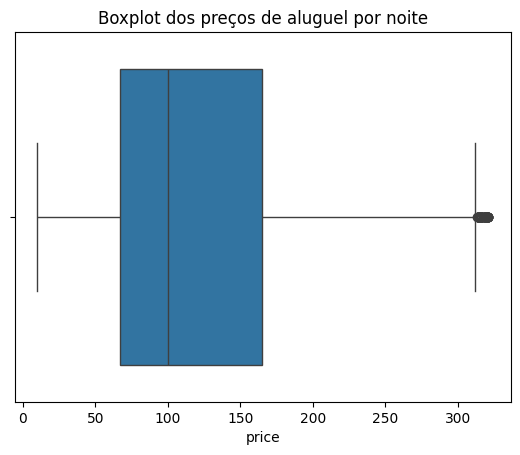

In [37]:
sns.boxplot(data=df, x=df['price'])
plt.title("Boxplot dos preços de aluguel por noite")
plt.show()

Após a análise dos preços, foi verificada a localização dos imóveis, para entender se existe algum padrão geográfico presente que possa ser levado em consideração.

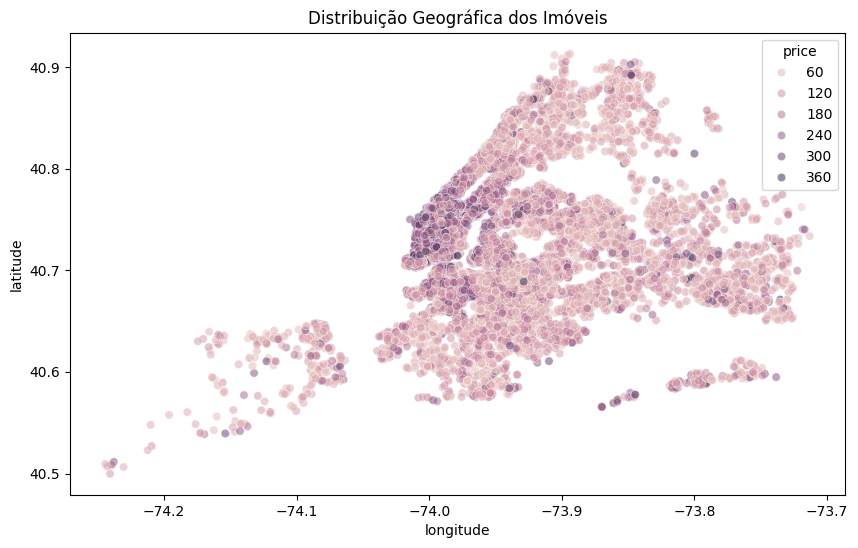

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['longitude'], y=df['latitude'], hue=df['price'], alpha=0.5)
plt.title("Distribuição Geográfica dos Imóveis")
plt.show()

Também foi feito o agrupamento de ofertas por bairro. Abaixo, a exibição do quantitativo geral e, em seguida, gráfico mostrando a variação.

In [ ]:
media_por_bairro = df.groupby('bairro_group')['price'].mean()
media_por_bairro.sort_values(ascending=False)

,price
bairro_group,
Manhattan,156.880865
Brooklyn,112.291103
Queens,91.303567
Staten Island,88.261538
Bronx,78.890747


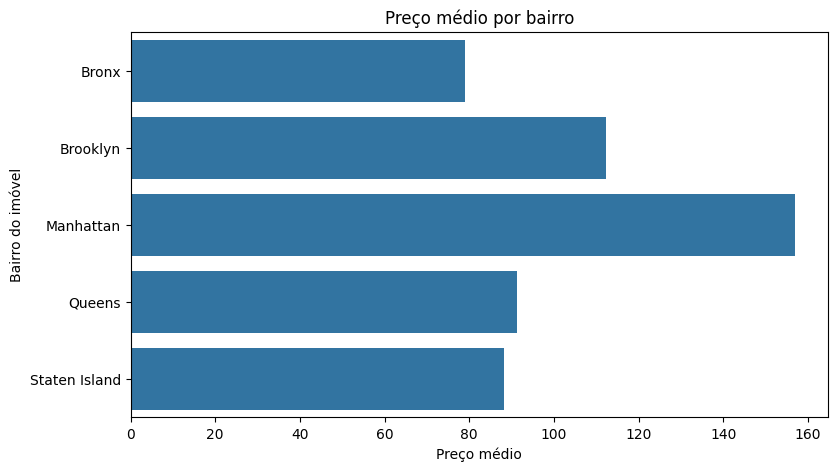

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(x=media_por_bairro.values, y=media_por_bairro.index)

plt.xlabel('Preço médio')
plt.ylabel('Bairro do imóvel')
plt.title('Preço médio por bairro')
plt.show()

O próximo passo foi analisar se o tipo de oferta tem influência direta no valor final do aluguel.

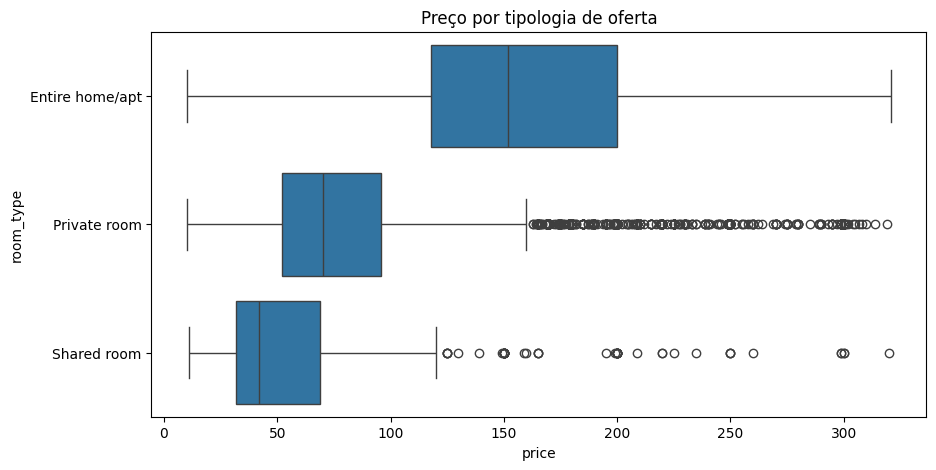

In [38]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'], y=df['room_type'])
plt.title("Preço por tipologia de oferta")
plt.show()

In [ ]:
df.groupby('room_type')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,14890.0,171.698925,70.083712,10.0,120.0,159.0,214.75,367.0
Private room,13752.0,81.743674,45.171982,10.0,52.0,70.0,98.00,365.0
Shared room,850.0,57.550588,43.648536,11.0,32.0,42.0,69.75,350.0


A seguir, a disponibilidade do local e o tempo mínimo de estadia foram analisado em busca de padrões, além do seu impacto no preço.

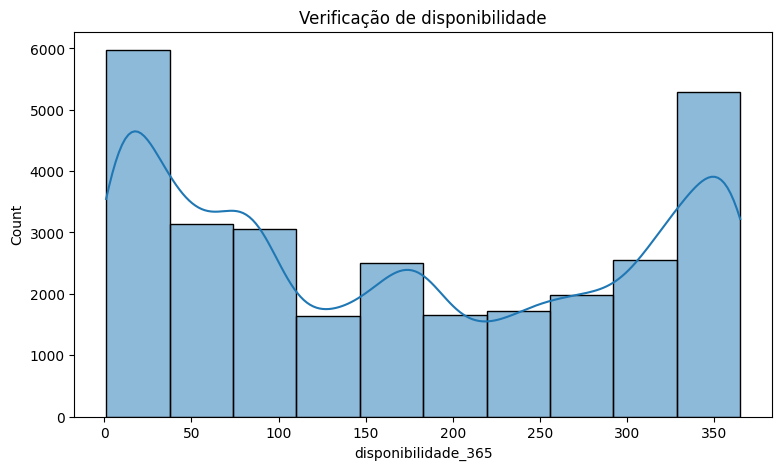

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(df['disponibilidade_365'], bins=10, kde=True)
plt.title("Verificação de disponibilidade")
plt.show()

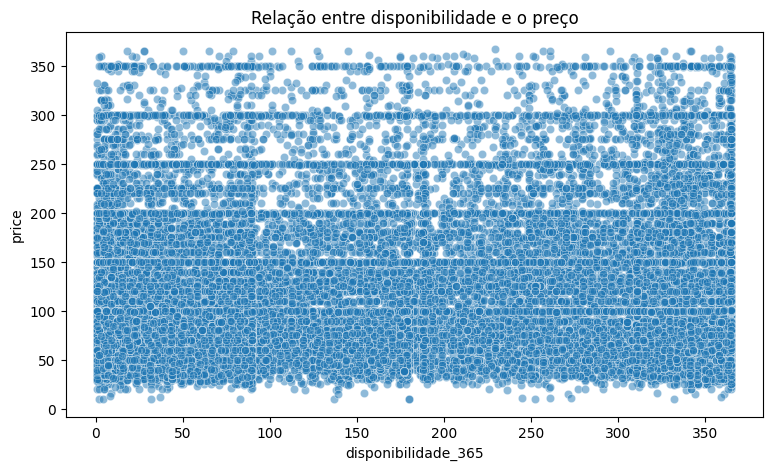

In [ ]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x=df['disponibilidade_365'], y=df['price'], alpha=0.5)
plt.title("Relação entre disponibilidade e o preço")
plt.show()

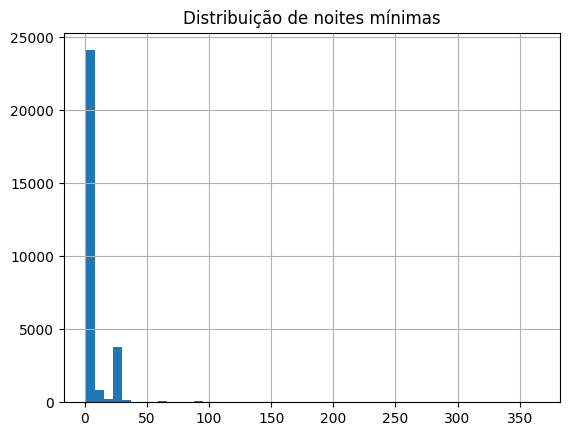

In [ ]:
df[df['minimo_noites'] < 365]['minimo_noites'].hist(bins=50)
plt.title("Distribuição de noites mínimas")
plt.show()

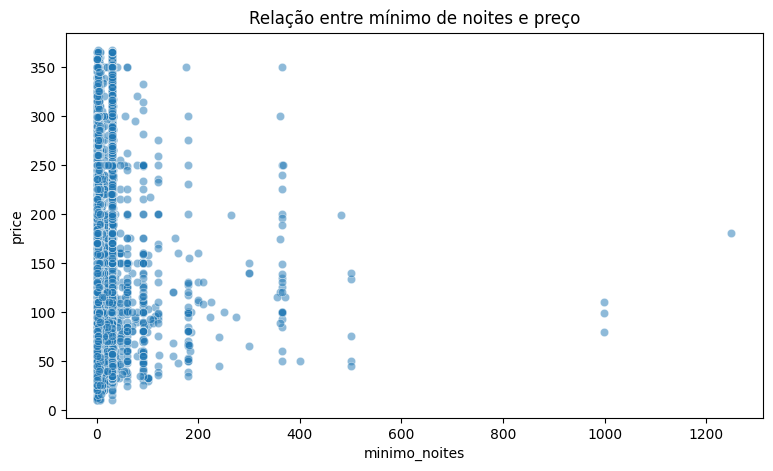

In [ ]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x=df['minimo_noites'], y=df['price'], alpha=0.5)
plt.title("Relação entre mínimo de noites e preço")
plt.show()

O próximo tópico analisando juntamente ao preço foram as reviews feitas pelos visitantes, seja na quantidade geral ou na verificação por mês.

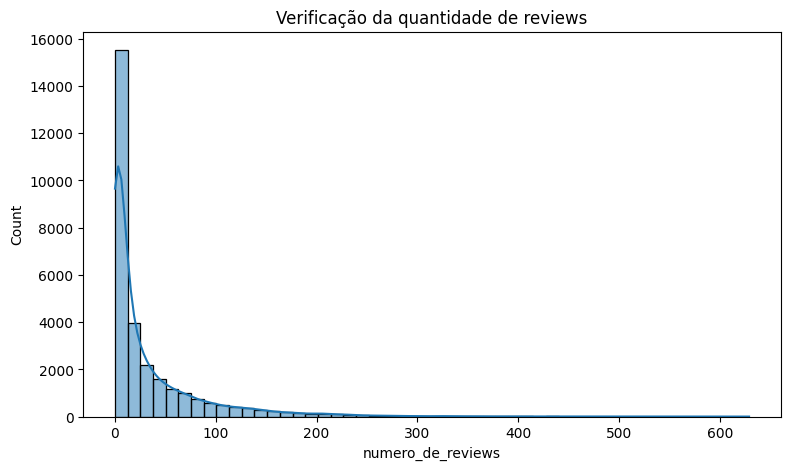

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(df['numero_de_reviews'], bins=50, kde=True)
plt.title("Verificação da quantidade de reviews")
plt.show()

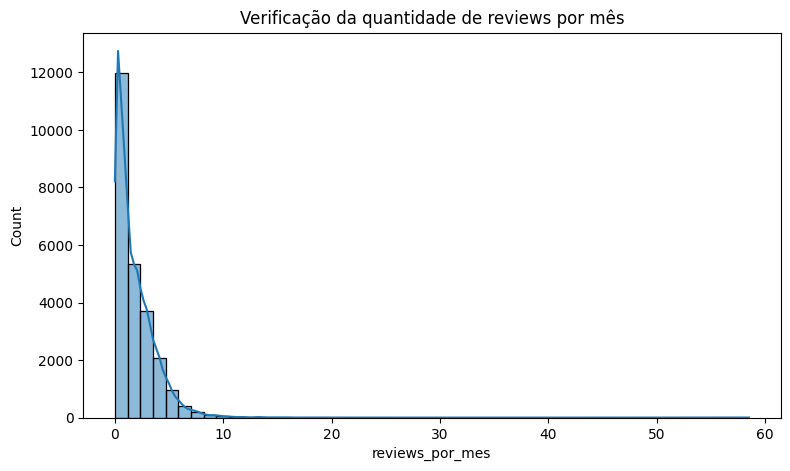

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(df['reviews_por_mes'], bins=50, kde=True)
plt.title("Verificação da quantidade de reviews por mês")
plt.show()

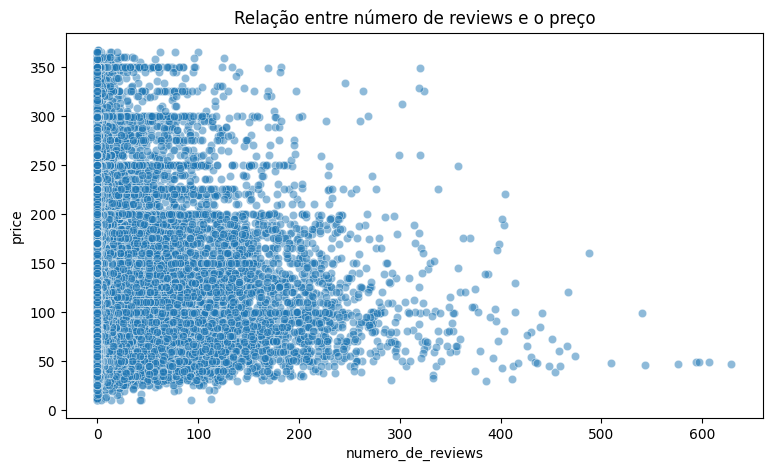

In [ ]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x=df['numero_de_reviews'], y=df['price'], alpha=0.5)
plt.title("Relação entre número de reviews e o preço")
plt.show()

A última verificação feita buscou entender se a nomenclatura do local interfere ou não no preço do aluguel.

In [ ]:
from collections import Counter

mediana_precos = df['price'].median()
nomes_mais_caros = " ".join(df[df['price'] > mediana_precos]['nome'].dropna().tolist()).lower().split()
nomes_mais_baratos = " ".join(df[df['price'] < mediana_precos]['nome'].dropna().tolist()).lower().split()

contagem_nomes_caros = sorted(Counter(nomes_mais_caros).most_common(20), key=lambda x: x[1], reverse=True)
contagem_nomes_baratos = sorted(Counter(nomes_mais_baratos).most_common(20), key=lambda x: x[1], reverse=True)

print("Quantidade de itens encontrados em anúncios caros:", len(contagem_nomes_caros))
print("Palavras mais comuns em anúncios caros:")
for palavra, contagem in contagem_nomes_caros:
    print(f" - {palavra}: {contagem}")

print("\nQuantidade de itens encontrados em anúncios baratos:", len(contagem_nomes_baratos))
print("Palavras mais comuns em anúncios baratos:")
for palavra, contagem in contagem_nomes_baratos:
    print(f" - {palavra}: {contagem}")

Quantidade de itens encontrados em anúncios caros: 20
Palavras mais comuns em anúncios caros:
 - in: 4232
 - apartment: 2145
 - bedroom: 1968
 - studio: 1556
 - 2: 1385
 - the: 1333
 - apt: 1332
 - private: 1232
 - 1: 1179
 - east: 1093
 - to: 1027
 - cozy: 1007
 - of: 997
 - brooklyn: 937
 - spacious: 922
 - park: 916
 - with: 912
 - &: 902
 - manhattan: 885
 - room: 814

Quantidade de itens encontrados em anúncios baratos: 20
Palavras mais comuns em anúncios baratos:
 - room: 4913
 - in: 4911
 - private: 3243
 - bedroom: 2033
 - cozy: 1837
 - to: 1735
 - brooklyn: 1178
 - apartment: 1175
 - manhattan: 1045
 - the: 1012
 - &: 958
 - and: 958
 - with: 957
 - near: 889
 - spacious: 832
 - a: 786
 - sunny: 720
 - from: 699
 - of: 696
 - -: 682
